<a href="https://colab.research.google.com/github/Ramya-sri123/Machine-Learning/blob/main/Linear_Regression_Handson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/new_insurance_data (1) (1).csv')
df


,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
df.shape

(1338, 13)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [ ]:
df.isna().sum()
df.rename(columns={'sex':'Gender'},inplace=True)
df

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
df.count()

,0
age,1329
sex,1338
bmi,1335
children,1333
smoker,1338
Claim_Amount,1324
past_consultations,1332
num_of_steps,1335
Hospital_expenditure,1334
NUmber_of_past_hospitalizations,1336


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:

for i in df.columns:
  if(df[i].dtype!='object'):
    df[i]=df[i].fillna(df[i].median())
df.isna().sum()


,0
age,0
Gender,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


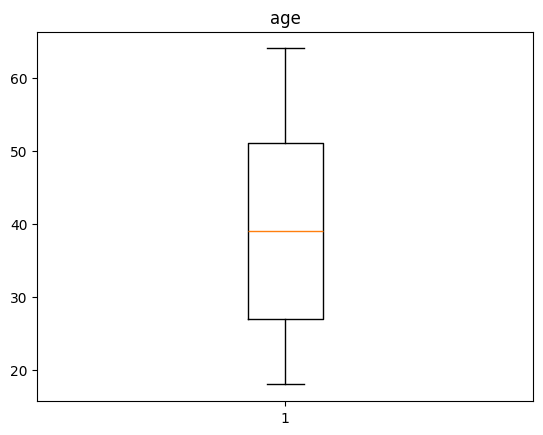

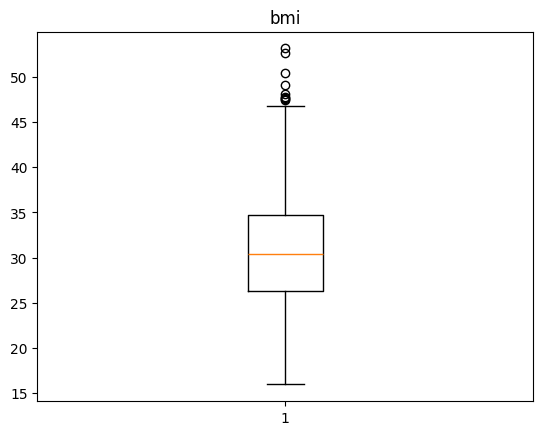

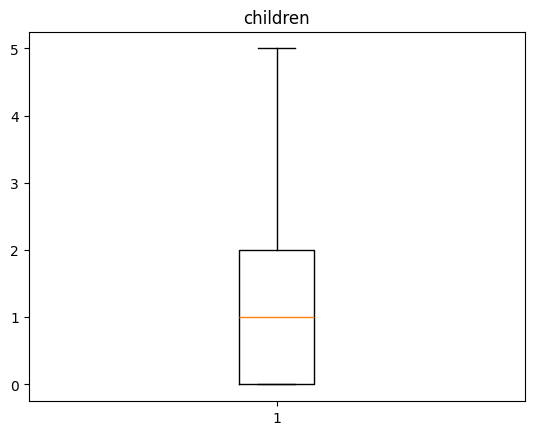

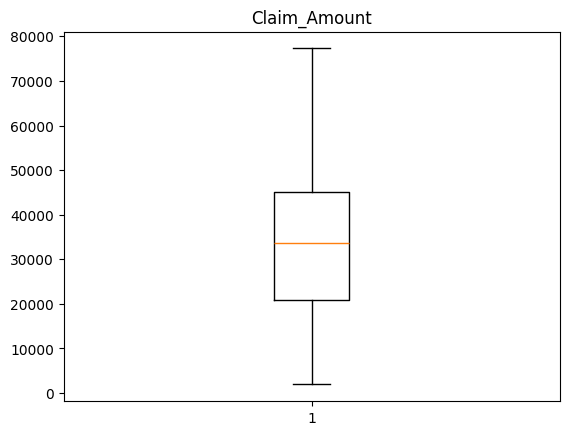

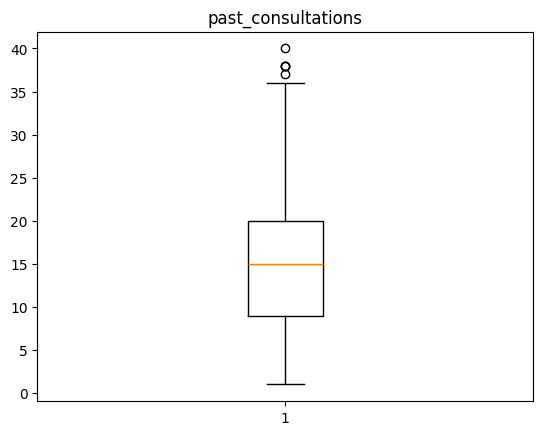

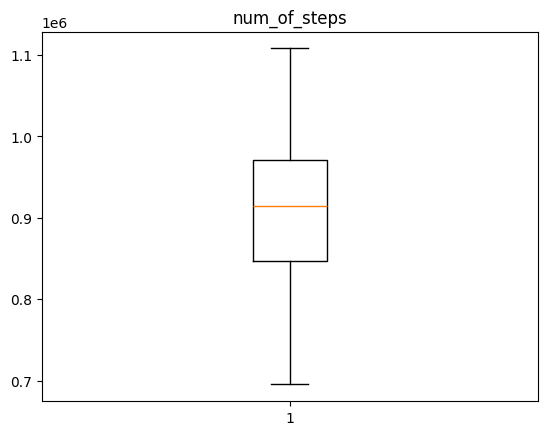

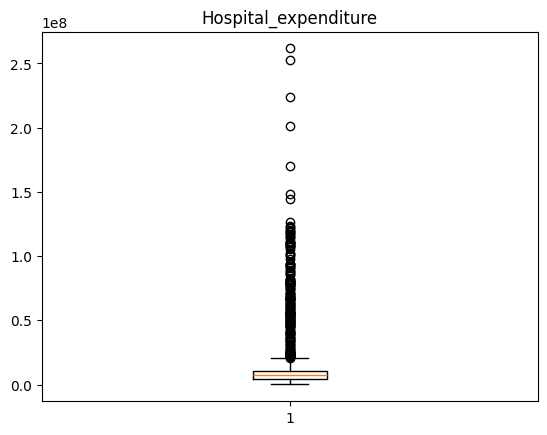

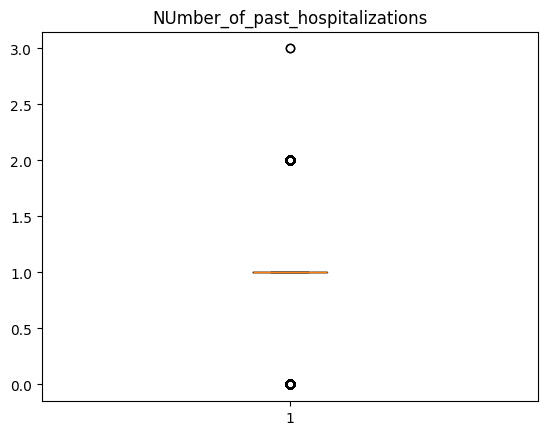

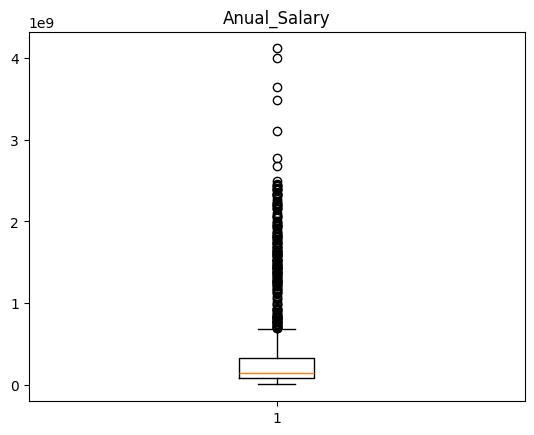

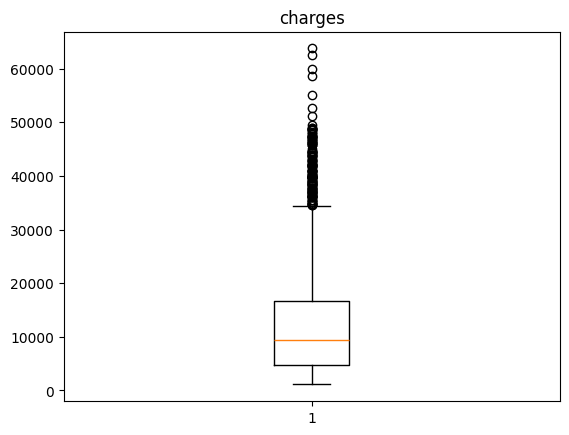

In [ ]:
import matplotlib.pyplot as plt

for i in df.columns:
  if(df[i].dtypes!='object'):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [ ]:
col=['bmi','past_consultations','Hospital_expenditure','Anual_Salary']
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  df=df[(df[i]>=lower) & (df[i]<=upper)]
df.head()

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


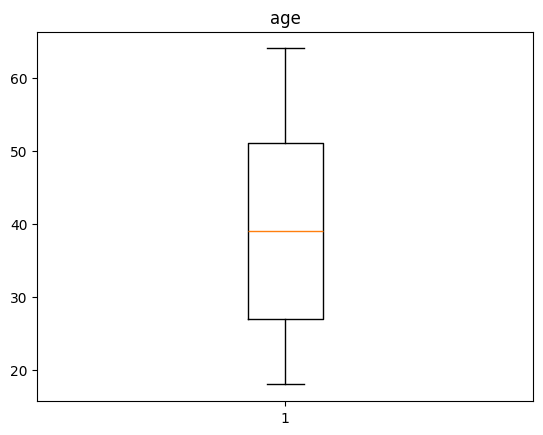

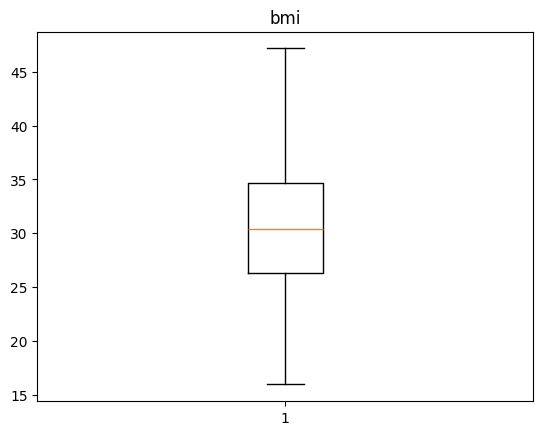

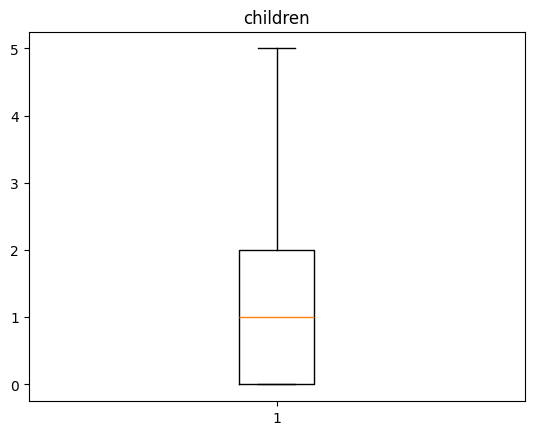

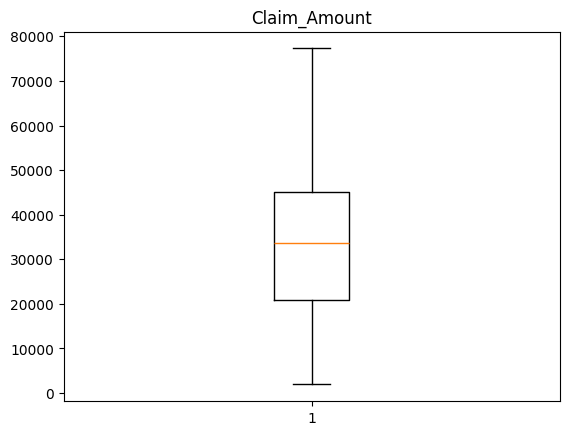

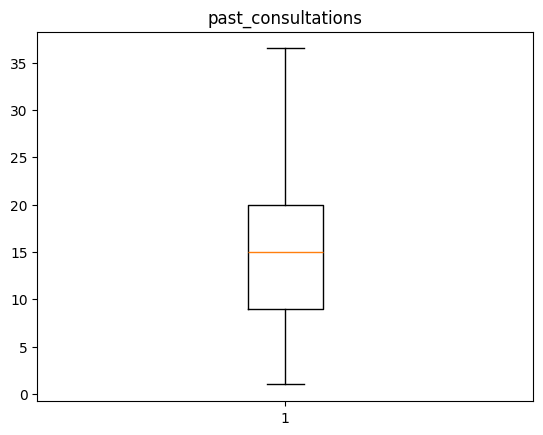

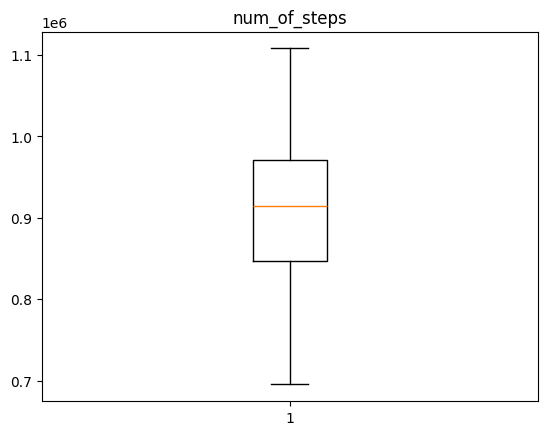

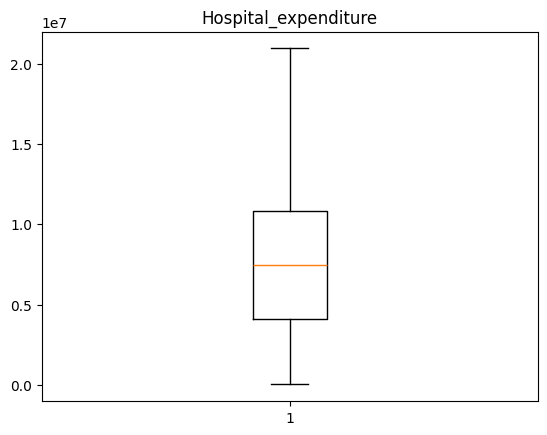

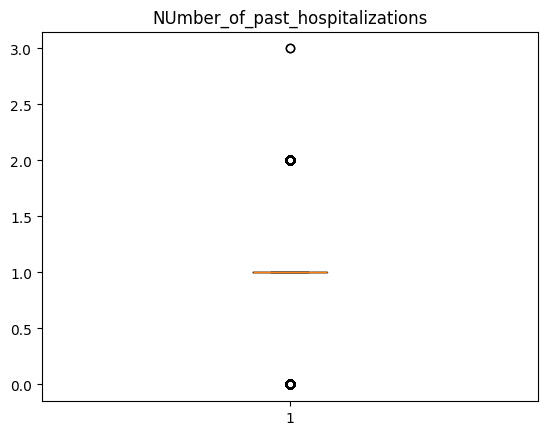

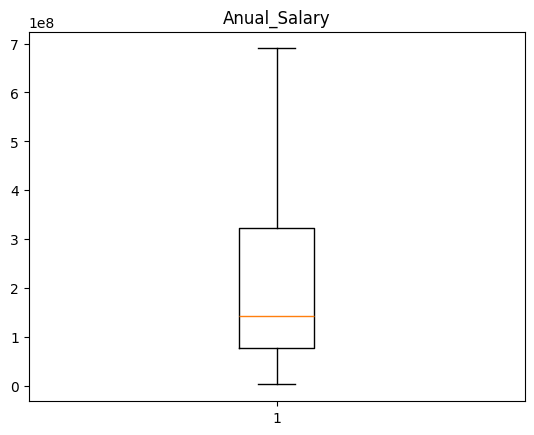

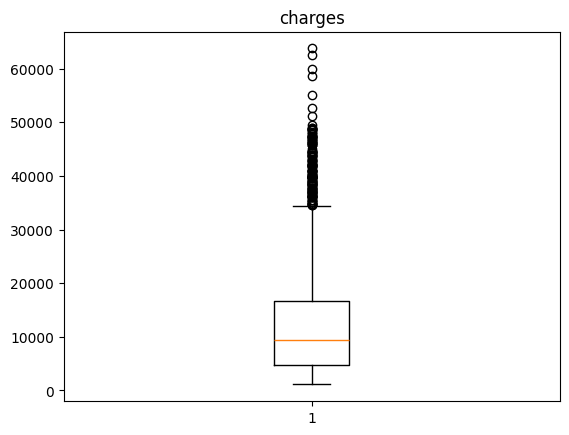

In [ ]:
for i in df.columns:
  if(df[i].dtypes!='object'):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if(df[i].dtypes=='object'):
    df[i]=le.fit_transform(df[i])
df.head()

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,2,1121.8739
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,2,1131.5066
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,2,1135.9407
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,2,1136.3994
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,2,1137.0110


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   Gender                           1338 non-null   int64  
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   int64  
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   num_of_steps                     1338 non-null   float64
 8   Hospital_expenditure             1338 non-null   float64
 9   NUmber_of_past_hospitalizations  1338 non-null   float64
 10  Anual_Salary                     1338 non-null   float64
 11  region                           1338 non-null   int64  
 12  charges             

In [ ]:
df[(df['Gender']==1) &(df['smoker']==0)]

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1176,55.0,1,37.715,3.0,0,60383.15233,26.0,1033197.0,2.093833e+07,2.0,6.899743e+08,1,30063.58055
1177,64.0,1,24.700,1.0,0,21006.56144,31.0,1044427.0,2.093833e+07,2.0,6.899743e+08,1,30166.61817
1179,60.0,1,28.595,0.0,0,58382.02948,18.0,1032051.0,2.093833e+07,2.0,6.899743e+08,0,30259.99556
1180,50.0,1,25.365,2.0,0,53161.54537,15.0,1029777.0,2.093833e+07,2.0,6.899743e+08,1,30284.64294


In [ ]:
x=df.drop('charges',axis=1)

y=df['charges']
x

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210000,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140000,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330000,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660000,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100000,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530000,0.0,1,63142.25346,32.0,1091267.0,2.093833e+07,2.0,6.899743e+08,1
1334,31.0,0,38.095000,1.0,1,43419.95227,31.0,1107872.0,2.093833e+07,2.0,6.899743e+08,0
1335,52.0,1,34.485000,3.0,1,52458.92353,25.0,1092005.0,2.093833e+07,2.0,6.899743e+08,1
1336,45.0,1,30.360000,0.0,1,69927.51664,34.0,1106821.0,2.093833e+07,3.0,6.899743e+08,2


In [ ]:
y.head()


,charges
0,1121.8739
1,1131.5066
2,1135.9407
3,1136.3994
4,1137.0110


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,age,Gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
560,45.0,0,35.815,0.0,0,29622.26103,6.0,886052.0,7.579867e+06,1.0,1.589946e+08,1
1285,44.0,0,38.950,0.0,1,66824.70947,23.0,1063413.0,2.093833e+07,2.0,6.899743e+08,1
1142,50.0,0,27.360,0.0,0,36320.75384,16.0,1001618.0,1.772151e+07,2.0,6.899743e+08,0
969,63.0,0,21.660,0.0,0,24827.43078,8.0,962113.0,1.214312e+07,1.0,2.928227e+08,0
486,34.0,0,19.000,3.0,0,47348.03370,10.0,888358.0,6.034962e+06,1.0,5.093163e+07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,59.0,1,37.400,0.0,0,47554.34106,19.0,1007896.0,1.132722e+07,1.0,5.662888e+08,3
1130,46.0,1,27.600,0.0,0,63672.07916,14.0,1000863.0,2.093833e+07,2.0,6.472972e+08,3
1294,54.0,1,34.210,2.0,1,42578.49702,24.0,1061168.0,2.093833e+07,2.0,6.899743e+08,2
860,58.0,0,36.480,0.0,0,27369.02461,22.0,943007.0,3.634140e+06,1.0,1.877743e+08,1


In [ ]:
y_train

,charges
560,7731.85785
1285,42983.45850
1142,25656.57526
969,14449.85440
486,6753.03800
...,...
1095,21797.00040
1130,24603.04837
1294,44260.74990
860,12235.83920


In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([ 1.15286904e+04,  1.35389299e+04,  1.12507042e+04,  3.76764065e+04,
        6.03818236e+03,  2.74180654e+04,  1.11532164e+04,  9.72745949e+03,
        3.65868576e+04,  1.09498040e+04,  1.09305700e+04,  9.33582905e+03,
       -1.85095422e+03,  5.10948684e+03,  1.20730800e+04,  1.40429087e+04,
        6.68511241e+03,  1.24684530e+04,  6.45661684e+03,  1.26656818e+04,
        7.31513413e+03,  1.00168731e+04,  8.37575426e+03,  2.18591521e+03,
        3.04068638e+04,  8.06660086e+03,  1.18023587e+04,  5.44521233e+03,
        6.36668120e+03,  1.12140348e+04,  3.70718696e+04,  1.20692241e+04,
        8.20985504e+03,  3.30999637e+04,  2.64503461e+04,  9.21314026e+03,
        6.78563216e+03,  3.69873621e+04,  3.26899080e+04,  2.71076346e+00,
        1.29649123e+03,  6.26658142e+03,  1.29585373e+04,  1.98608023e+04,
        7.37793263e+03,  4.01596745e+03, -2.66962603e+02,  1.17058926e+04,
        2.22659751e+03,  4.01938856e+03,  8.86847037e+03,  3.48507183e+03,
        1.27073693e+04,  

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.933815690978097
10580635.892156888


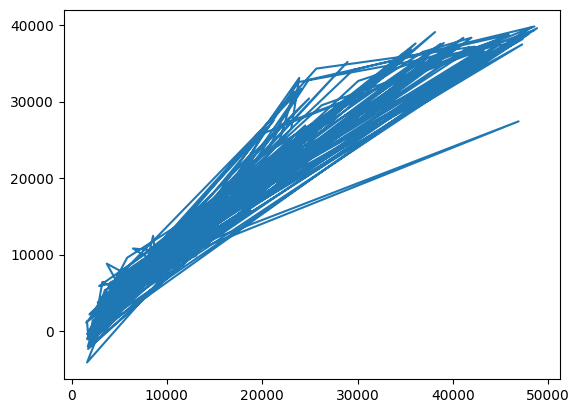

In [ ]:
plt.plot(y_test,y_pred)
plt.show()